# Deep Learning for Player Action Prediction from Atari Gameplay Frames

**Student:** Robert Mayfield  
**Course:** Udacity AI Masters Capstone, Project 4: Deep Learning Systems

---

In [6]:
import sys
import io
import json
import zipfile
import tarfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# ensure project root is on the path before importing src
sys.path.insert(0, str(Path('..').resolve()))

# project utilities — all dl_utils imports consolidated here
from src.dl_utils import (
    load_all_sessions,
    GameFrameDataset,
    SessionAwareStackedDataset,
    ActionCNN,
    train_one_epoch,
    eval_epoch,
    evaluate_model,
    save_checkpoint,
    load_checkpoint,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU:     {torch.cuda.get_device_name(0)}')

PyTorch: 2.6.0+cu124
Device:  cuda
GPU:     NVIDIA GeForce RTX 3080


In [7]:
%matplotlib inline

In [8]:
PROJECT_ROOT   = Path('..').resolve()

ATARI_ZIP      = PROJECT_ROOT / 'data' / 'raw' / 'montezuma_revenge.zip'
FIGURES_DIR    = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR     = PROJECT_ROOT / 'outputs' / 'tables'
ARTIFACTS_DIR  = PROJECT_ROOT / 'outputs' / 'model_artifacts'
SAMPLE_DIR     = PROJECT_ROOT / 'data' / 'sample'

for d in [FIGURES_DIR, TABLES_DIR, ARTIFACTS_DIR, SAMPLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 84
STACK_SIZE   = 4
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-4
N_ACTIONS    = 5
ACTION_NAMES = ['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN']

ALE_TO_CLASS = {
    0: 0, 1: 0,                               # NOOP, FIRE -> NOOP
    3: 1, 6: 1, 8: 1, 11: 1, 14: 1, 16: 1,   # rightward moves and fire combos
    4: 2, 7: 2, 9: 2, 12: 2, 13: 2, 15: 2,   # leftward moves and fire combos
    2: 3, 10: 3,                               # UP, UPFIRE -> UP
    5: 4,                                      # DOWN
}

print(f'ZIP found: {ATARI_ZIP.exists()}')
print('Configuration ready.')

ZIP found: True
Configuration ready.


## 1. Project Overview

This project trains a convolutional neural network to predict player actions from Atari Montezuma's Revenge gameplay frames using real human demonstration data. Montezuma's Revenge is a side scrolling platformer requiring jumping, ladder climbing, key collection, and hazard avoidance. This is directly relevant to the platformer behavior modeling goals of the AI Game Director Studio.

**Research question:** Does providing the model with four consecutive frames of temporal context improve action prediction over a single static frame?

**Dataset:** Atari-HEAD (Zhang et al., 2020) - 27 sessions, 447,327 frames, one human player.

**Controlled comparison:** Baseline uses a single frame (in_channels=1). Experimental model uses four stacked consecutive frames (in_channels=4). Architecture, optimizer, loss function, and training duration are held constant.

**Primary metric:** Macro F1, because UP and DOWN are mild minority classes (~10% each). Accuracy is reported as a secondary metric.

## 2. Dataset Loading and Inspection

In [9]:
try:
    frames
    print(f'Data already in memory — {len(frames):,} frames, skipping load.')
except NameError:
    print('Loading all Montezuma Revenge sessions from zip archive...')
    print('All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).')
    print()
    frames, labels, session_lengths, session_meta = load_all_sessions(
        zip_path=ATARI_ZIP,
        img_size=IMG_SIZE,
        ale_to_class=ALE_TO_CLASS,
    )
    print()
    print(f'Total frames loaded : {len(frames):>10,}')
    print(f'Total sessions      : {len(session_meta):>10}')
    print(f'Frame array shape   : {str(frames.shape):>10}')
    print(f'Frame dtype         : {str(frames.dtype):>10}')
    print(f'Label dtype         : {str(labels.dtype):>10}')
    print(f'RAM usage (uint8)   : {frames.nbytes / 1024**3:>9.2f} GB')

Loading all Montezuma Revenge sessions from zip archive...
All frames are preloaded to CPU RAM as uint8 (normalisation deferred to DataLoader).

  standard   284_RZ_5540489_Apr-17-17-38-18 ... 15,651 frames
  standard   285_RZ_5619207_Apr-18-15-28-46 ... 16,494 frames
  standard   287_RZ_7172481_May-06-14-59-10 ... 16,194 frames
  standard   291_RZ_7364933_May-08-20-23-25 ... 16,721 frames
  standard   324_RZ_452975_Jun-13-14-10-23 ... 15,895 frames
  standard   333_RZ_900705_Jun-18-18-32-58 ... 16,687 frames
  standard   340_RZ_1323550_Jun-23-15-59-54 ... 17,053 frames
  standard   359_RZ_1993616_Jul-01-10-09-26 ... 17,096 frames
  standard   365_RZ_2079996_Jul-02-10-07-22 ... 17,067 frames
  standard   371_RZ_2173469_Jul-03-12-05-16 ... 16,547 frames
  standard   385_RZ_2344725_Jul-05-11-46-58 ... 16,956 frames
  standard   398_RZ_2530473_Jul-07-15-16-40 ... 16,883 frames
  standard   402_RZ_2603283_Jul-08-11-28-49 ... 17,054 frames
  standard   416_RZ_2788252_Jul-10-14-52-12 ... 16,

In [10]:
# Session summary table
session_df = pd.DataFrame(session_meta)
session_df.index = range(1, len(session_df) + 1)
session_df.columns = ['Session', 'Type', 'Frames']
session_df = session_df[['Session', 'Type', 'Frames']]

print(f'{"#":<4} {"Type":<12} {"Frames":>8}   Session')
print('-' * 70)
for i, row in session_df.iterrows():
    print(f'{i:<4} {row["Type"]:<12} {row["Frames"]:>8,}   {row["Session"]}')
print('-' * 70)
print(f'{"TOTAL":<17} {sum(session_lengths):>8,}')
print(f'\nStandard sessions : {sum(1 for m in session_meta if m["type"] == "standard")}')
print(f'Highscore sessions: {sum(1 for m in session_meta if m["type"] == "highscore")}')
print(f'Min frames/session: {min(session_lengths):,}')
print(f'Max frames/session: {max(session_lengths):,}')
print(f'Avg frames/session: {sum(session_lengths)/len(session_lengths):,.0f}')

#    Type           Frames   Session
----------------------------------------------------------------------
1    standard       15,651   284_RZ_5540489_Apr-17-17-38-18
2    standard       16,494   285_RZ_5619207_Apr-18-15-28-46
3    standard       16,194   287_RZ_7172481_May-06-14-59-10
4    standard       16,721   291_RZ_7364933_May-08-20-23-25
5    standard       15,895   324_RZ_452975_Jun-13-14-10-23
6    standard       16,687   333_RZ_900705_Jun-18-18-32-58
7    standard       17,053   340_RZ_1323550_Jun-23-15-59-54
8    standard       17,096   359_RZ_1993616_Jul-01-10-09-26
9    standard       17,067   365_RZ_2079996_Jul-02-10-07-22
10   standard       16,547   371_RZ_2173469_Jul-03-12-05-16
11   standard       16,956   385_RZ_2344725_Jul-05-11-46-58
12   standard       16,883   398_RZ_2530473_Jul-07-15-16-40
13   standard       17,054   402_RZ_2603283_Jul-08-11-28-49
14   standard       16,992   416_RZ_2788252_Jul-10-14-52-12
15   standard       16,935   429_RZ_2945490_Jul-12-10-

In [11]:
# Frame property inspection
print('Frame pixel statistics:')
sample_idx = np.random.default_rng(SEED).integers(0, len(frames), size=10_000)
sample = frames[sample_idx].astype(np.float32)
print(f'  Min pixel value  : {frames.min()}')
print(f'  Max pixel value  : {frames.max()}')
print(f'  Mean (10k sample): {sample.mean():.2f}')
print(f'  Std  (10k sample): {sample.std():.2f}')
print()
print('Label value range:')
print(f'  Unique labels: {sorted(np.unique(labels).tolist())}')
print(f'  Expected     : {list(range(N_ACTIONS))} ({ACTION_NAMES})')

Frame pixel statistics:
  Min pixel value  : 0
  Max pixel value  : 235
  Mean (10k sample): 42.14
  Std  (10k sample): 51.45

Label value range:
  Unique labels: [0, 1, 2, 3, 4]
  Expected     : [0, 1, 2, 3, 4] (['NOOP', 'RIGHT', 'LEFT', 'UP', 'DOWN'])


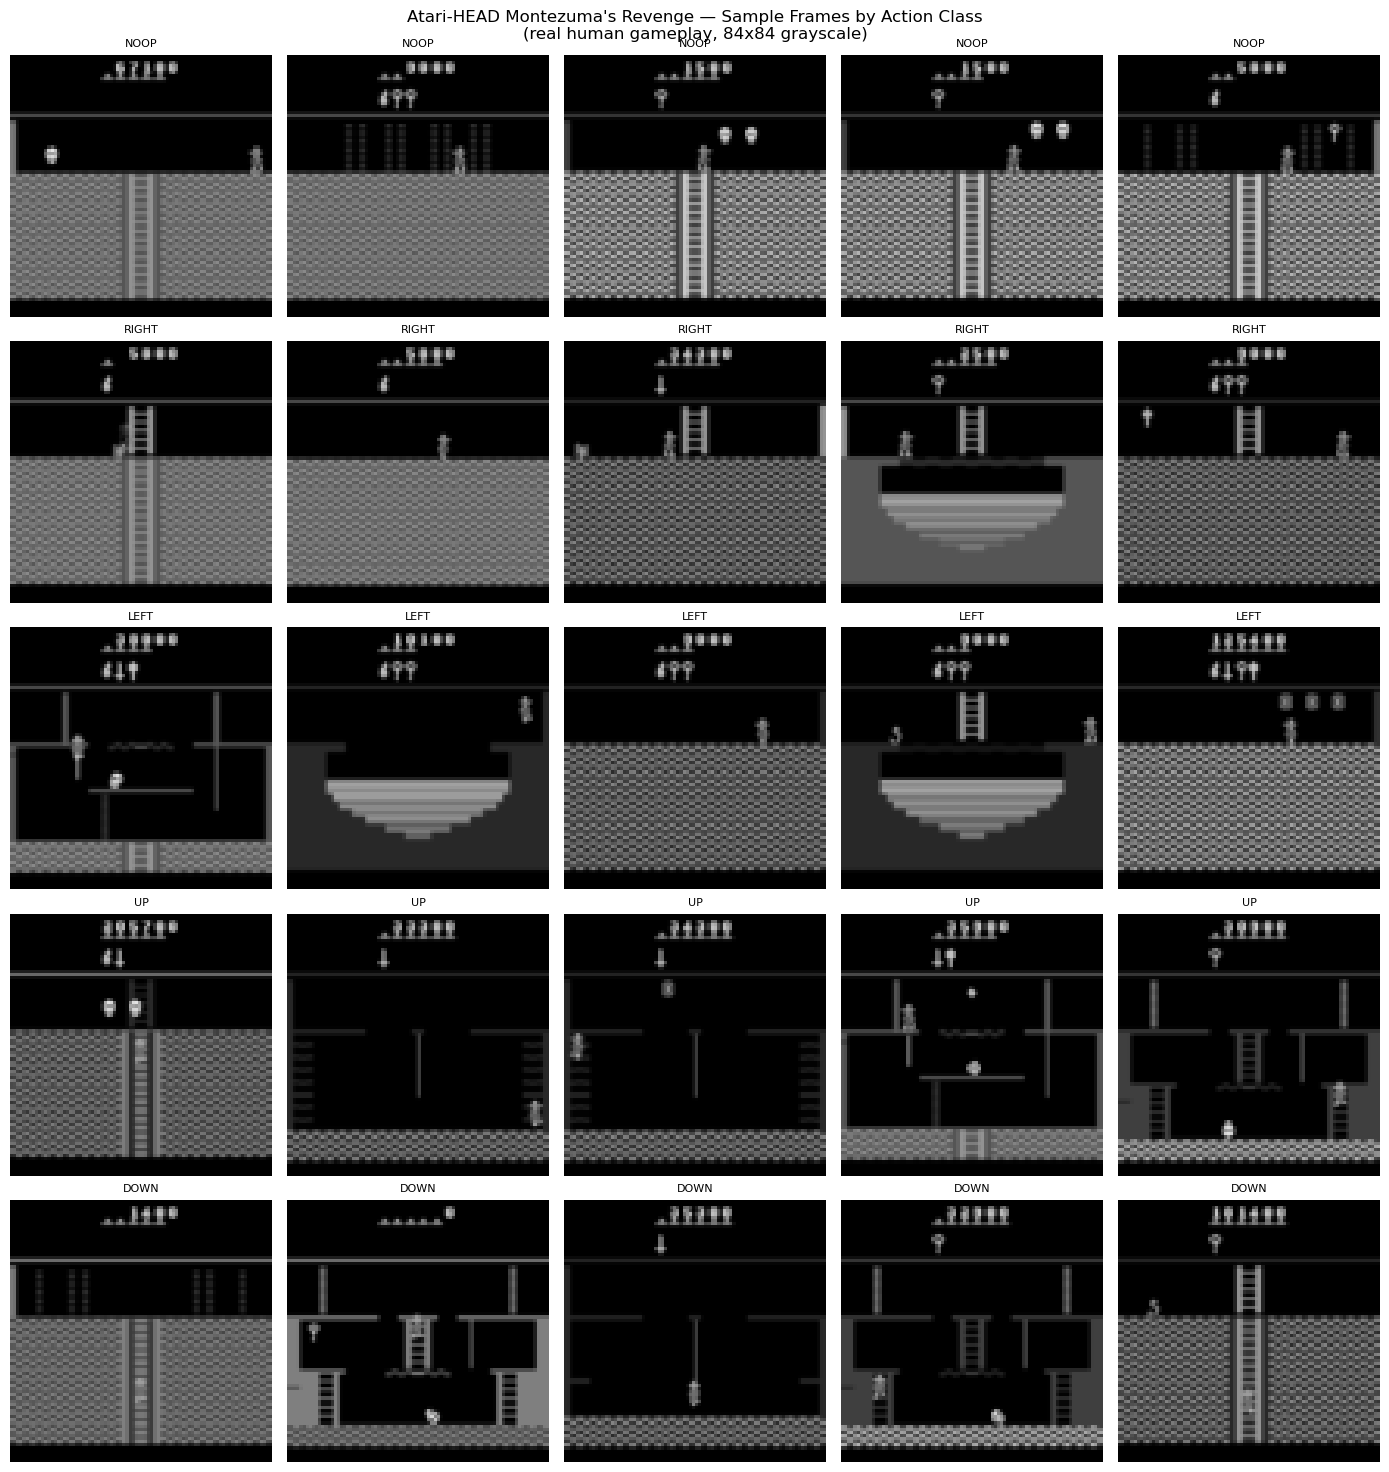

Figure saved to outputs/figures/sample_frames_by_class.png


In [12]:
# Sample frames — one row per action class showing representative gameplay moments
fig, axes = plt.subplots(N_ACTIONS, 5, figsize=(14, 3 * N_ACTIONS))

for cls in range(N_ACTIONS):
    cls_indices = np.where(labels == cls)[0]
    chosen = np.random.default_rng(SEED + cls).choice(cls_indices, size=5, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[cls, col]
        ax.imshow(frames[idx], cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{ACTION_NAMES[cls]}', fontsize=8)
        ax.axis('off')

fig.suptitle(
    'Atari-HEAD Montezuma\'s Revenge — Sample Frames by Action Class\n'
    '(real human gameplay, 84x84 grayscale)',
    fontsize=12,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'sample_frames_by_class.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/sample_frames_by_class.png')

**Dataset inspection findings.** All 447,327 frames loaded successfully across 27 sessions. Frames are stored as 84x84 grayscale uint8 arrays (~3.2 GB total in CPU RAM), with pixel values ranging from 0 to 255. All five action classes are present in the label array. The sample frames show recognizable Montezuma's Revenge gameplay elements: the starting room with ladders, platforms, keys, and the skull enemy. Visual differences between action classes are subtle in static frames, which motivates a four frame stacking approach in the experimental model. No missing frames or label anomalies were detected during loading.

## 3. Data Preprocessing

In [13]:
# Session-level train / val / test split (70 / 15 / 15)
# Splitting at session level prevents any frame from one session appearing in
# both training and evaluation, avoiding data leakage between splits.
rng = np.random.default_rng(SEED)
shuffled = rng.permutation(len(session_meta))

n_train = 19   # 19 + 4 + 4 = 27
n_val   = 4

train_sess_idx = shuffled[:n_train]
val_sess_idx   = shuffled[n_train:n_train + n_val]
test_sess_idx  = shuffled[n_train + n_val:]

# Build cumulative start positions so we can slice by session index
sess_starts = np.concatenate([[0], np.cumsum(session_lengths)])

def collect_split(sess_indices: np.ndarray) -> tuple[np.ndarray, np.ndarray, list[int]]:
    """Concatenate frames and labels for a set of session indices.

    Returns frames array, labels array, and per-session lengths
    needed by SessionAwareStackedDataset to respect boundaries.
    """
    f_parts, l_parts, lengths = [], [], []
    for i in sorted(sess_indices):
        s, e = int(sess_starts[i]), int(sess_starts[i + 1])
        f_parts.append(frames[s:e])
        l_parts.append(labels[s:e])
        lengths.append(e - s)
    return np.concatenate(f_parts), np.concatenate(l_parts), lengths

train_frames, train_labels, train_lengths = collect_split(train_sess_idx)
val_frames,   val_labels,   val_lengths   = collect_split(val_sess_idx)
test_frames,  test_labels,  test_lengths  = collect_split(test_sess_idx)

print(f'Sessions  — train: {len(train_sess_idx)}  val: {len(val_sess_idx)}  test: {len(test_sess_idx)}')
print(f'Frames    — train: {len(train_frames):,}  val: {len(val_frames):,}  test: {len(test_frames):,}')

Sessions  — train: 19  val: 4  test: 4
Frames    — train: 314,929  val: 65,620  test: 66,751


In [14]:
# Class weights — computed from training labels only, never from val or test
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_ACTIONS),
    y=train_labels,
)
weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print('Class weights (training set):')
for i, (name, w) in enumerate(zip(ACTION_NAMES, class_weights)):
    count = int((train_labels == i).sum())
    print(f'  {name:<8} count={count:>7,}  weight={w:.4f}')

Class weights (training set):
  NOOP     count= 81,880  weight=0.7692
  RIGHT    count= 80,589  weight=0.7816
  LEFT     count= 88,340  weight=0.7130
  UP       count= 30,407  weight=2.0714
  DOWN     count= 33,713  weight=1.8683


In [15]:
# Dataset objects — single-frame (baseline) and session-boundary-aware stacked (experimental)
train_ds_base  = GameFrameDataset(train_frames, train_labels)
val_ds_base    = GameFrameDataset(val_frames,   val_labels)
test_ds_base   = GameFrameDataset(test_frames,  test_labels)

train_ds_stack = SessionAwareStackedDataset(train_frames, train_labels, train_lengths, STACK_SIZE)
val_ds_stack   = SessionAwareStackedDataset(val_frames,   val_labels,   val_lengths,   STACK_SIZE)
test_ds_stack  = SessionAwareStackedDataset(test_frames,  test_labels,  test_lengths,  STACK_SIZE)

# Verify shapes
xb, yb = train_ds_base[0]
xs, ys = train_ds_stack[0]
print(f'Baseline  sample shape: {xb.shape}  label: {yb.item()}')
print(f'Stacked   sample shape: {xs.shape}  label: {ys.item()}')

Baseline  sample shape: torch.Size([1, 84, 84])  label: 0
Stacked   sample shape: torch.Size([4, 84, 84])  label: 0


In [16]:
# DataLoaders — num_workers=0 required on Windows (fork not available)
train_loader_base  = DataLoader(train_ds_base,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_base    = DataLoader(val_ds_base,    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_base   = DataLoader(test_ds_base,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

train_loader_stack = DataLoader(train_ds_stack, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_stack   = DataLoader(val_ds_stack,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_stack  = DataLoader(test_ds_stack,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders created.')
print(f'  Baseline  — train batches: {len(train_loader_base):,}  val: {len(val_loader_base):,}  test: {len(test_loader_base):,}')
print(f'  Stacked   — train batches: {len(train_loader_stack):,}  val: {len(val_loader_stack):,}  test: {len(test_loader_stack):,}')

DataLoaders created.
  Baseline  — train batches: 4,921  val: 1,026  test: 1,043
  Stacked   — train batches: 4,920  val: 1,026  test: 1,043


In [ ]:
# Split summary
header = f'{"Split":<10} {"Sessions":>9} {"Frames (base)":>15} {"Samples (stacked)":>18}'
print(header)
print('-' * len(header))
for split_name, n_sess, ds_base, ds_stack in [
    ('Train',      len(train_sess_idx), train_ds_base, train_ds_stack),
    ('Validation', len(val_sess_idx),   val_ds_base,   val_ds_stack),
    ('Test',       len(test_sess_idx),  test_ds_base,  test_ds_stack),
]:
    print(f'{split_name:<10} {n_sess:>9} {len(ds_base):>15,} {len(ds_stack):>18,}')
print('-' * len(header))
print(f'{"Total":<10} {len(session_meta):>9} {len(frames):>15,} {len(train_ds_stack)+len(val_ds_stack)+len(test_ds_stack):>18,}')
print()
print('Note: stacked dataset has fewer samples because 4 frame windows')
print('      cannot start in the last 3 frames of each session.')

Split       Sessions   Frames (base)  Samples (stacked)
-------------------------------------------------------
Train             19         314,929            314,872
Validation         4          65,620             65,608
Test               4          66,751             66,739
-------------------------------------------------------
Total             27         447,300            447,219

Note: stacked dataset has fewer samples because 4-frame windows
      cannot start in the last 3 frames of each session.


**Preprocessing summary.** Frames are split at the session level rather than the frame level to prevent data leakage: no session contributes frames to more than one split. The 19/4/4 session allocation provides roughly 70/15/15 proportions by frame count. Class weights are derived from training labels only, giving higher weight to the minority UP and DOWN classes to counteract their lower frequency. The stacked dataset has slightly fewer total samples than the baseline because four frame windows cannot extend beyond session boundaries, losing up to three samples per session boundary.

## 4. Label Distribution and Class Imbalance

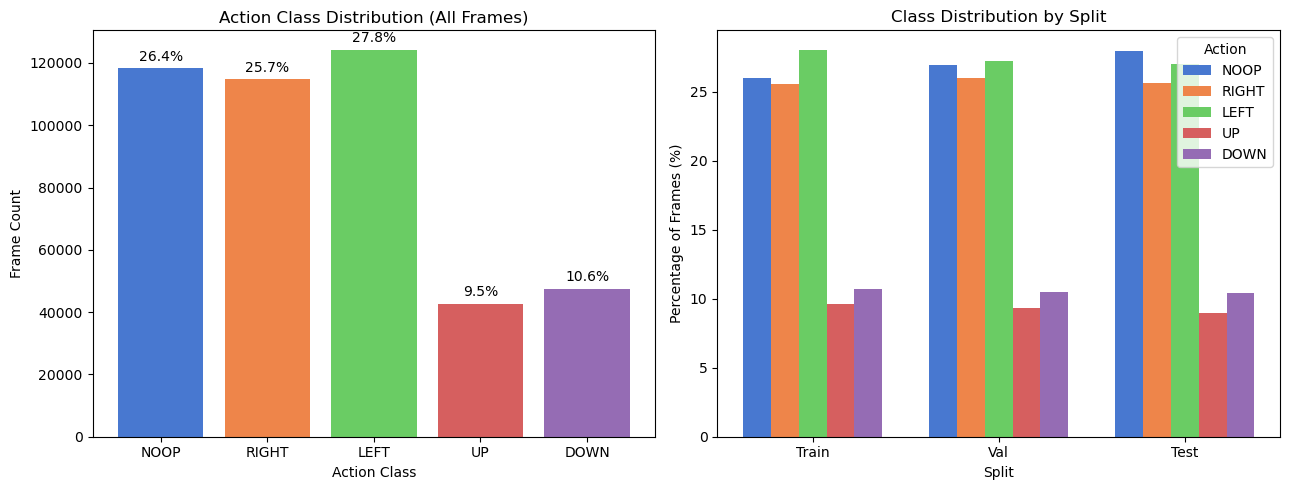

Figure saved to outputs/figures/class_distribution.png

Class distribution (full dataset):
  NOOP    : 118,203  (26.4%)
  RIGHT   : 114,753  (25.7%)
  LEFT    : 124,241  (27.8%)
  UP      :  42,557  (9.5%)
  DOWN    :  47,546  (10.6%)


In [25]:
counts = Counter(labels.tolist())
total  = len(labels)
pcts   = [counts[i] / total * 100 for i in range(N_ACTIONS)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall class distribution
bars = axes[0].bar(ACTION_NAMES, [counts[i] for i in range(N_ACTIONS)],
                   color=sns.color_palette('muted', N_ACTIONS))
axes[0].set_title('Action Class Distribution (All Frames)')
axes[0].set_xlabel('Action Class')
axes[0].set_ylabel('Frame Count')
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1500,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Right: class distribution by split
split_pcts = {}
for split_name, split_labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    n = len(split_labels)
    split_pcts[split_name] = [(split_labels == i).sum() / n * 100 for i in range(N_ACTIONS)]

x      = np.arange(3)
width  = 0.15
colors = sns.color_palette('muted', N_ACTIONS)
for cls_i in range(N_ACTIONS):
    axes[1].bar(x + (cls_i - 2) * width,
                [split_pcts[s][cls_i] for s in ['Train', 'Val', 'Test']],
                width, label=ACTION_NAMES[cls_i], color=colors[cls_i])
axes[1].set_title('Class Distribution by Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Percentage of Frames (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Train', 'Val', 'Test'])
axes[1].legend(title='Action', loc='upper right')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/class_distribution.png')
print()
print('Class distribution (full dataset):')
for i, name in enumerate(ACTION_NAMES):
    print(f'  {name:<8}: {counts[i]:>7,}  ({pcts[i]:.1f}%)')

**Class distribution findings.** The dataset has three dominant classes that are nearly equal in frequency: LEFT (27.8%), NOOP (26.4%), and RIGHT (25.7%). UP (9.5%) and DOWN (10.6%) are the minority classes, representing the less frequent but tactically important ladder and rope traversal actions in Montezuma's Revenge. The relatively balanced distribution among the three dominant classes reflects natural platformer movement patterns, while the roughly 3-to-1 ratio between the dominant and minority classes is mild enough that macro F1 remains a fair primary metric. Class weighted cross entropy loss is applied during training to ensure UP and DOWN receive proportional gradient influence. Class proportions are consistent across the train, validation, and test splits, confirming that the session level random split did not concentrate any action class in a single partition.

## 5. Baseline Model Implementation

In [19]:
# placeholder — implemented in Section 5

## 6. Baseline Model Training

In [20]:
# placeholder — implemented in Section 6

## 7. Experimental Comparison Design

In [21]:
# placeholder — implemented in Section 7

## 8. Experimental Model Training

In [22]:
# placeholder — implemented in Section 8

## 9. Evaluation and Comparison

In [23]:
# placeholder — implemented in Section 9

## 10. Error Analysis and Failure Cases

In [24]:
# placeholder — implemented in Section 10

## 11. Limitations, Risks, and Responsible Use

placeholder — written in Section 11

## 12. Future Integration with AI Game Director Studio

placeholder — written in Section 12

## 13. Final Notebook Summary

placeholder — written in Section 13

## References

placeholder — written at end